<div style="color:blue">

**Programming for Data Science (UFCFVQ-15-M)**

**Assignment - Part 2**

This part of the assignment focuses on using
NumPy/SciPy, Pandas, and Matplotlib/Seaborn
to combine and analyse two datasets related to bike shares.

## Overview

Part 2

  - Q2.1: explore data [20 marks]
  - Q2.2: detect and remove outliers [10 marks]
  - Q2.3: hypothesis test [10 marks]

For each of the questions Q2.1-Q2.4 there is a blank *Markdown* cell
for explanations, formulas, etc. and
a blank *code* cell for Python code.
You can add more cells.
Any explanations can be entered as Markdown or as comments with the code.
You do not have to use LaTeX (the markup language that can be used
to typeset formulas in Jupyter Notebook files).
You do have to make sure that any notation you use is clear.


## Marking Guideline
The marks for each question are indicated above.

There is not necessarily a relation between the number of marks for a question
and the amount of work required or the level of difficulty.
You may find some questions more difficult than others.

Try to answer as many questions as you can.


Q2.1

- 0: no answer, irrelevant or incorrect answer
- 1-4: insufficient and/or many mistakes
- 5-8: acceptable, but incomplete and/or substantial mistakes
- 9-12: good, substantial answer, with good explanation
- 13-16: very good, mostly complete, only minor mistake or issue with explanation
- 17-20: excellent, complete answer with clear and concise explanation

Q2.2-3

- 0: no answer, irrelevant or incorrect answer
- 1,2: insufficient and/or many mistakes
- 3,4: acceptable, but incomplete and/or substantial mistakes
- 5,6: good, substantial answer, with good explanation
- 7,8: very good, mostly complete, only minor mistake or issue with explanation
- 9,10: excellent, complete answer with clear and concise explanation

Note that the pass mark for postgraduate assessments is 50%.

<div style="color:blue">

# Part 2
To obtain good marks, you should make both your writing and your code clear, correct and concise.

</div>

In [1]:
# Put all the import statements for this notebook in this cell.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<div style="color:blue">

## Q2.1: Explore the Dataset to Identify an Interesting Pattern or Trend [20 marks]

Use appropriate visualisations (using, for example,  Matplotlib or Seaborn)
to illustrate your exploration.
You should include at least three visualisations as part of your exploration.
You could consider other ways to explore the data such as data summaries or
transformations.
You must include an explanation of the dataset exploration, your selected
interesting pattern or trend and your reasons for selecting it.
</div>


## Dataset Exploration
The two CSV files contain hourly bike share data for London. part2a.csv includes the timestamp and the number of new bike shares each hour. part2b.csv includes weather information for each hour, such as temperature, humidity, wind speed, and whether it was a weekend.

I merged the two files using the timestamp so I could analyse everything in one place. The combined dataset has 17,414 rows and no missing values.

I explored the data using three visualisations. Figure 1 shows that hourly bike-share counts are right-skewed, which means most hours have relatively low usage but a few hours have very high usage. Spring has the highest usage and Winter the lowest, which fits the weather pattern.

Figure 2 compares weekday and weekend usage across the seasons. Weekday usage is higher in every season. This is interesting because weekends might be expected to be busier for leisure cycling, but the opposite happens, which suggests that people mainly use the bikes for commuting.

Figure 3 supports this idea. There is a moderate positive relationship between temperature and bike usage, with r = 0.389, which means warmer weather encourages more cycling. The hourly pattern is even clearer: weekdays show two peaks around 8am and 5–6pm, which matches morning and evening rush hours. Weekends only show one broad midday peak, with no rush-hour pattern.

The main pattern I found is that weekday usage is much higher than weekend usage, and this seems to be driven by commuting rather than leisure. This suggests that Transport for London should focus on making bikes available near workplaces and transport hubs during weekday rush hours.

In [11]:

# Load the two CSV files
df_a = pd.read_csv('part2a.csv', parse_dates=['timestamp'])
df_b = pd.read_csv('part2b.csv', parse_dates=['timestamp'])

# Merge on the timestamp column
df = pd.merge(df_a, df_b, on='timestamp')

# Make sure the timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Add season names
season_map = {0: 'Winter', 1: 'Spring', 2: 'Summer', 3: 'Autumn'}
df['season'] = df['season_code'].map(season_map)

# Add weekday/weekend labels
df['day_type'] = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

print('Dataset shape:', df.shape)
print()
print('Summary statistics:')
print(df[['new_bike_shares', 'temperature', 'humidity', 'wind_speed']].describe().round(2))
print()
print('Missing values:', df.isnull().sum().sum())


Dataset shape: (17414, 10)

Summary statistics:
       new_bike_shares  temperature  humidity  wind_speed
count         17414.00     17414.00  17414.00    17414.00
mean           1143.10        12.47     72.32       15.91
std            1085.11         5.57     14.31        7.89
min               0.00        -1.50     20.50        0.00
25%             257.00         8.00     63.00       10.00
50%             844.00        12.50     74.50       15.00
75%            1671.75        16.00     83.00       20.50
max            7860.00        34.00    100.00       56.50

Missing values: 0


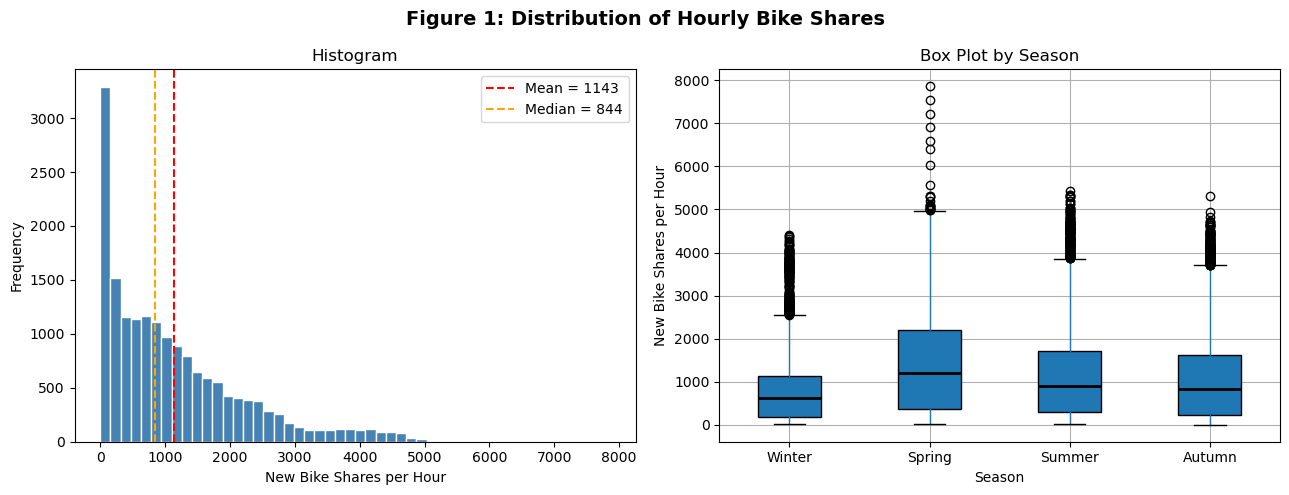

Seasonal mean bike shares:
season
Autumn     821.7
Spring    1464.5
Summer    1179.0
Winter    1103.8


In [14]:
# Visualisation 1: Distribution of hourly bike shares
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1: Distribution of Hourly Bike Shares', fontsize=14, fontweight='bold')

# Histogram of hourly bike shares
axes[0].hist(df['new_bike_shares'], bins=50, color='steelblue', edgecolor='white')
# Add mean and median lines
axes[0].axvline(df['new_bike_shares'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f"Mean = {df['new_bike_shares'].mean():.0f}")
axes[0].axvline(df['new_bike_shares'].median(), color='orange', linestyle='--',
                linewidth=1.5, label=f"Median = {df['new_bike_shares'].median():.0f}")
axes[0].set_xlabel('New Bike Shares per Hour')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram')
axes[0].legend()

# Box plot of bike shares by season
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
colours = ['#5DA5DA', '#60BD68', '#F17CB0', '#FAA43A']
df.boxplot(column='new_bike_shares', by='season', ax=axes[1],
           positions=range(4), patch_artist=True,
           boxprops=dict(color='black'),
           medianprops=dict(color='black', linewidth=2))
axes[1].set_xticklabels(season_order)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('New Bike Shares per Hour')
axes[1].set_title('Box Plot by Season')
plt.suptitle('')   # remove the auto title from boxplot
fig.suptitle('Figure 1: Distribution of Hourly Bike Shares', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('Seasonal mean bike shares:')
print(df.groupby('season')['new_bike_shares'].mean().round(1).to_string())

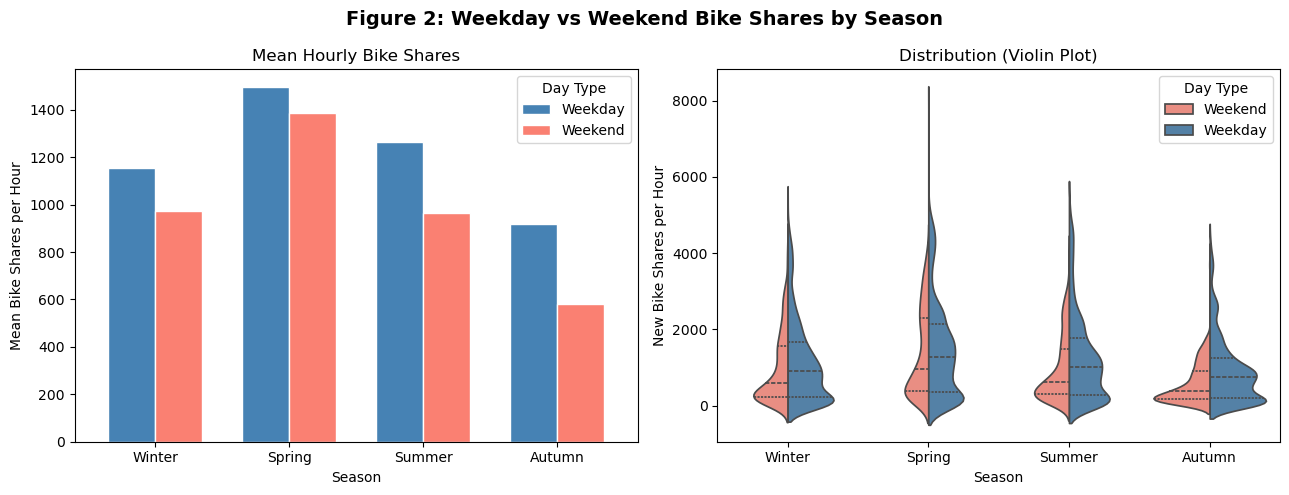

Mean bike shares — Weekday vs Weekend by Season:
day_type  Weekday  Weekend
season                    
Winter     1155.3    975.1
Spring     1495.8   1385.5
Summer     1264.1    965.1
Autumn      918.1    582.1


In [23]:
# Visualisation 2: Bike shares by season and day type
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2: Weekday vs Weekend Bike Shares by Season',
             fontsize=14, fontweight='bold')

# Bar chart of mean bike shares by season and day type
grouped = df.groupby(['season', 'day_type'])['new_bike_shares'].mean().unstack()
grouped = grouped.reindex(season_order)
grouped.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'],
             edgecolor='white', width=0.7)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Mean Bike Shares per Hour')
axes[0].set_title('Mean Hourly Bike Shares')
axes[0].set_xticklabels(season_order, rotation=0)
axes[0].legend(title='Day Type')

# Distribution comparison (violin plot)
sns.violinplot(data=df, x='season', y='new_bike_shares', hue='day_type',
               order=season_order, split=True, ax=axes[1],
               palette={'Weekday': 'steelblue', 'Weekend': 'salmon'},
               inner='quartile')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('New Bike Shares per Hour')
axes[1].set_title('Distribution (Violin Plot)')
axes[1].legend(title='Day Type')

plt.tight_layout()
plt.show()

print('Mean bike shares — Weekday vs Weekend by Season:')
print(grouped.round(1).to_string())

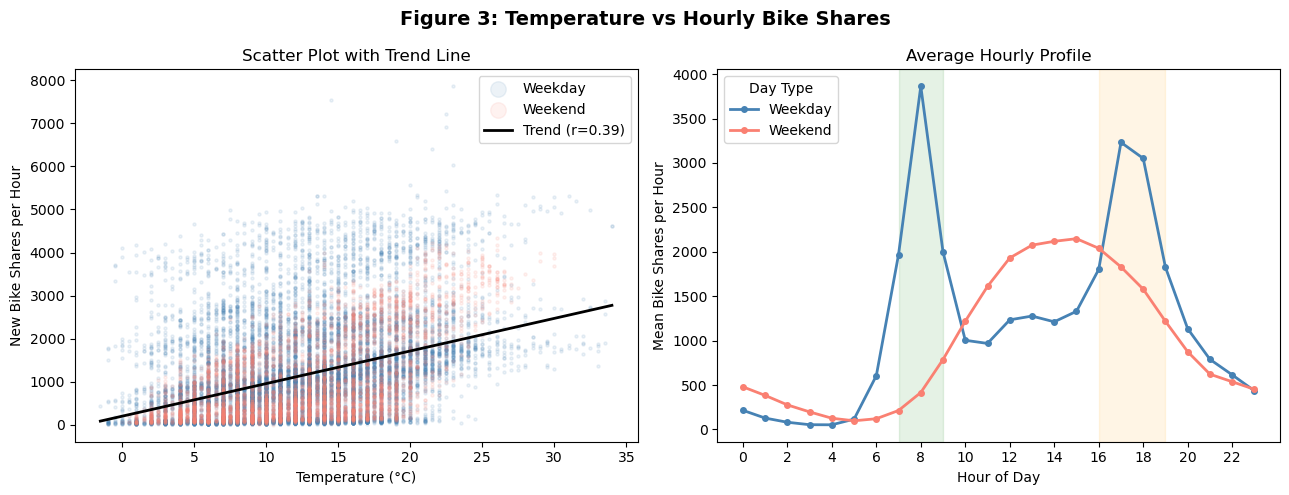

Pearson correlation (temperature vs bike shares): r = 0.389
Regression: bike_shares = 75.7 * temperature + 199.0


In [16]:
# Visualisation 3: Temperature vs bike shares (scatter + trend)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3: Temperature vs Hourly Bike Shares',
             fontsize=14, fontweight='bold')

# Scatter plot coloured by weekday/weekend
for day, colour in [('Weekday', 'steelblue'), ('Weekend', 'salmon')]:
    subset = df[df['day_type'] == day]
    axes[0].scatter(subset['temperature'], subset['new_bike_shares'],
                    alpha=0.1, s=5, color=colour, label=day)

# Add overall trend line
slope, intercept, r, p_val, _ = stats.linregress(df['temperature'],
                                                   df['new_bike_shares'])
x_line = np.linspace(df['temperature'].min(), df['temperature'].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept,
             color='black', linewidth=2, label=f'Trend (r={r:.2f})')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('New Bike Shares per Hour')
axes[0].set_title('Scatter Plot with Trend Line')
axes[0].legend(markerscale=5)

# Average bike shares for each hour of the day
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby(['hour', 'day_type'])['new_bike_shares'].mean().unstack()
hourly['Weekday'].plot(ax=axes[1], color='steelblue',
                       linewidth=2, label='Weekday', marker='o', markersize=4)
hourly['Weekend'].plot(ax=axes[1], color='salmon',
                       linewidth=2, label='Weekend', marker='o', markersize=4)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Bike Shares per Hour')
axes[1].set_title('Average Hourly Profile')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(title='Day Type')
axes[1].axvspan(7, 9, alpha=0.1, color='green', label='AM rush')
axes[1].axvspan(16, 19, alpha=0.1, color='orange', label='PM rush')

plt.tight_layout()
plt.show()

print(f'Pearson correlation (temperature vs bike shares): r = {r:.3f}')
print(f'Regression: bike_shares = {slope:.1f} * temperature + {intercept:.1f}')


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/20
</div>

<div style="color:blue">

## Q2.2: Detect and Remove Any Outliers in the Data Used for Your Interesting Pattern [10 marks]

Use an appropriate technique to detect and remove any outliers in the data
used for your interesting pattern or trend.
You must include an explanation of the detection method used, how it works,
and any outliers detected.
NOTE: there may not be any detectable outliers using the selected detection
method –
if this is the case, please state this clearly in the explanation given.
</div>




## Outlier Detection Using the IQR Method

To find unusual values in the new_bike_shares column, I used the IQR method.

I chose this method instead of z-scores because the data is right-skewed, and z-scores work best when the data is close to a normal distribution. The IQR method is a better fit here because it does not assume a particular shape for the data.

First, I calculated Q1 and Q3. Q1 is the value below which 25% of the data falls, and Q3 is the value below which 75% of the data falls. Then I calculated the IQR using Q3 - Q1. After that, I worked out the lower and upper boundaries using Q1 - 1.5 × IQR and Q3 + 1.5 × IQR.

Any value above the upper boundary was treated as an outlier. In this dataset, I found 675 outliers, which is 3.9% of the data. All of these outliers were above the upper boundary, so they were hours with unusually high bike usage. After removing them, I was left with 16,739 clean rows for the rest of the analysis.

The box plot and histogram show the difference before and after removing these outliers.

Q1             : 257.0
Q3             : 1671.75
IQR            : 1414.75
Lower boundary    : -1865.12
Upper boundary    : 3793.88

Total rows         : 17414
Outliers detected  : 675 (3.9%)
Rows after cleaning: 16739

Outlier bike share statistics:
count     675.00
mean     4336.10
std       449.23
min      3794.00
25%      4011.00
50%      4263.00
75%      4571.00
max      7860.00
Name: new_bike_shares, dtype: float64


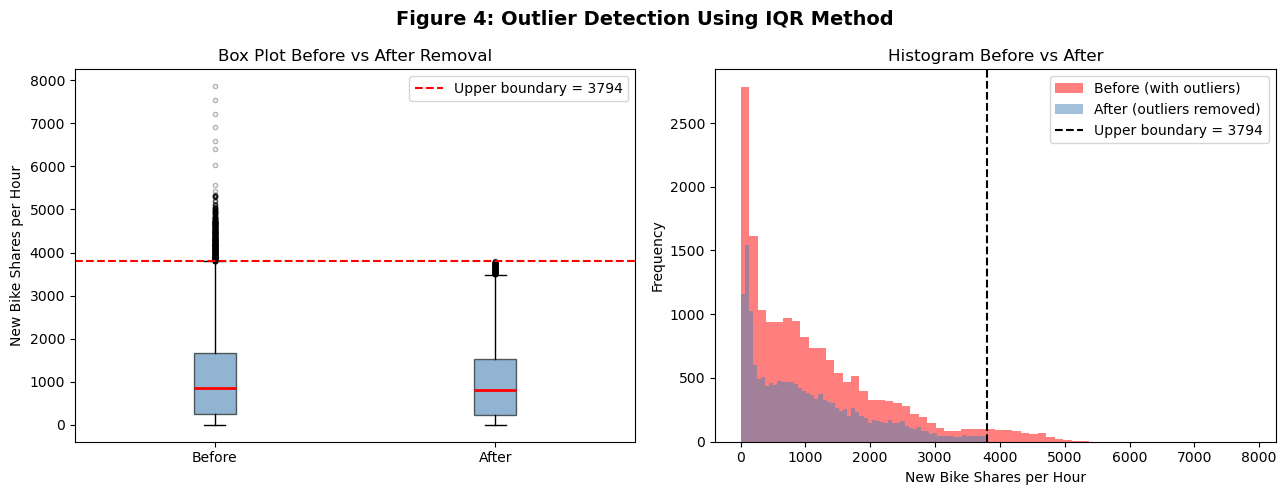

In [19]:

# Outlier detection using the IQR method
Q1  = df['new_bike_shares'].quantile(0.25)
Q3  = df['new_bike_shares'].quantile(0.75)
IQR = Q3 - Q1

lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR

print(f'Q1             : {Q1}')
print(f'Q3             : {Q3}')
print(f'IQR            : {IQR}')
print(f'Lower boundary    : {lower_boundary:.2f}')
print(f'Upper boundary    : {upper_boundary:.2f}')

# Find outliers
outliers    = df[df['new_bike_shares'] > upper_boundary]
df_clean    = df[df['new_bike_shares'] <= upper_boundary].copy()

print(f'\nTotal rows         : {len(df)}')
print(f'Outliers detected  : {len(outliers)} ({100*len(outliers)/len(df):.1f}%)')
print(f'Rows after cleaning: {len(df_clean)}')
print()
print('Outlier bike share statistics:')
print(outliers['new_bike_shares'].describe().round(2))

# Visualising the data before and after removing outliers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4: Outlier Detection Using IQR Method',
             fontsize=14, fontweight='bold')

# Box plot comparison
axes[0].boxplot([df['new_bike_shares'], df_clean['new_bike_shares']],
                tick_labels=['Before', 'After'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='red', markersize=3, alpha=0.3))
axes[0].set_ylabel('New Bike Shares per Hour')
axes[0].set_title('Box Plot Before vs After Removal')
axes[0].axhline(upper_boundary, color='red', linestyle='--',
                linewidth=1.5, label=f'Upper boundary = {upper_boundary:.0f}')
axes[0].legend()

# Histogram comparison
axes[1].hist(df['new_bike_shares'], bins=60, alpha=0.5,
             color='red', label='Before (with outliers)', edgecolor='none')
axes[1].hist(df_clean['new_bike_shares'], bins=60, alpha=0.5,
             color='steelblue', label='After (outliers removed)', edgecolor='none')
axes[1].axvline(upper_boundary, color='black', linestyle='--',
                linewidth=1.5, label=f'Upper boundary = {upper_boundary:.0f}')
axes[1].set_xlabel('New Bike Shares per Hour')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram Before vs After')
axes[1].legend()

plt.tight_layout()
plt.show()


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>

<div style="color:blue">

## Q2.3: Hypothesis Test [10 marks]

Define a hypothesis using an appropriate hypothesis testing formulation.
Provide an explanation for your choice.
Using an appropriate Python library, test this hypothesis.
You must include a detailed explanation of your findings to achieve good marks for this task.
</div>

## Hypothesis Test

Based on the pattern found in Q2.1, I wanted to check whether weekday bike usage is really higher than weekend usage, or whether the difference could just be due to chance.

The null hypothesis is that the average number of hourly bike shares on weekdays is the same as on weekends. The alternative hypothesis is that weekday bike shares are higher than weekend bike shares.

I used a one-tailed independent samples t-test because the two groups are separate, I am comparing the means of a numerical variable, and I had a clear direction in mind. I expected weekday usage to be higher, not just different. The sample sizes are also large enough for the test to be reliable.

After removing outliers, the weekday group had 11,807 hours with a mean of 1,039.44 and a standard deviation of 886.38. The weekend group had 4,932 hours with a mean of 954.26 and a standard deviation of 890.12.

The test gave a t-statistic of 5.6616 and a p-value of 7.6 x 10^-9, which is far below 0.05. So I reject the null hypothesis.

This means there is strong evidence that weekday bike shares are significantly higher than weekend bike shares. On average, weekday usage is about 9% higher than weekend usage, which suggests the bike share system is mainly used for commuting rather than weekend leisure.

Group summary (after outlier removal):
  Weekday — n=11,807, mean=1039.44, std=886.38
  Weekend — n=4,932, mean=954.26, std=890.12

Independent samples t-test (one-tailed, weekday > weekend):
  t-statistic : 5.6616
  p-value     : 7.62e-09
  Alpha       : 0.05

Decision: REJECT H0
There is statistically significant evidence that weekday bike shares are higher than weekend bike shares.


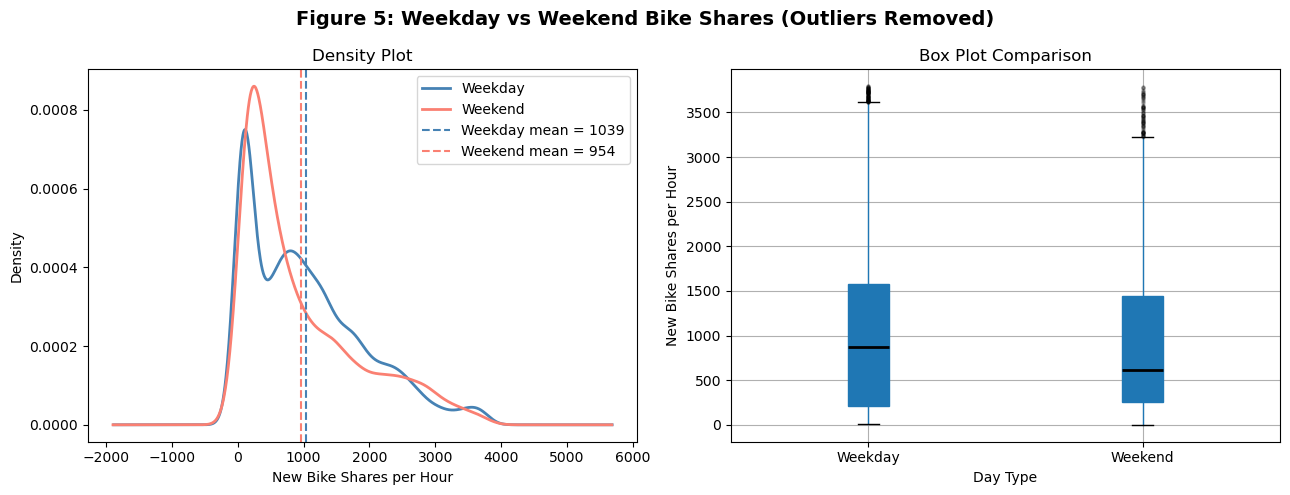

In [21]:
# Hypothesis test on the cleaned dataset
weekday_shares = df_clean[df_clean['is_weekend'] == 0]['new_bike_shares']
weekend_shares = df_clean[df_clean['is_weekend'] == 1]['new_bike_shares']

print('Group summary (after outlier removal):')
print(f'  Weekday — n={len(weekday_shares):,}, mean={weekday_shares.mean():.2f}, '
      f'std={weekday_shares.std():.2f}')
print(f'  Weekend — n={len(weekend_shares):,}, mean={weekend_shares.mean():.2f}, '
      f'std={weekend_shares.std():.2f}')
print()

# One-tailed independent samples t-test
# alternative='greater' tests H1: mean(weekday) > mean(weekend)
t_stat, p_value = stats.ttest_ind(weekday_shares, weekend_shares,
                                   alternative='greater')

alpha = 0.05
print(f'Independent samples t-test (one-tailed, weekday > weekend):')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_value:.2e}')
print(f'  Alpha       : {alpha}')
print()

if p_value < alpha:
    print('Decision: REJECT H0')
    print('There is statistically significant evidence that weekday bike shares'
          ' are higher than weekend bike shares.')
else:
    print('Decision: FAIL TO REJECT H0')
    print('There is insufficient evidence to conclude weekday usage is higher.')

# Visualising the two distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 5: Weekday vs Weekend Bike Shares (Outliers Removed)',
             fontsize=14, fontweight='bold')

# Density plot (KDE)
weekday_shares.plot.kde(ax=axes[0], color='steelblue',
                        linewidth=2, label='Weekday')
weekend_shares.plot.kde(ax=axes[0], color='salmon',
                        linewidth=2, label='Weekend')
axes[0].axvline(weekday_shares.mean(), color='steelblue',
                linestyle='--', linewidth=1.5,
                label=f'Weekday mean = {weekday_shares.mean():.0f}')
axes[0].axvline(weekend_shares.mean(), color='salmon',
                linestyle='--', linewidth=1.5,
                label=f'Weekend mean = {weekend_shares.mean():.0f}')
axes[0].set_xlabel('New Bike Shares per Hour')
axes[0].set_ylabel('Density')
axes[0].set_title('Density Plot')
axes[0].legend()

# Box plot comparison
df_clean.boxplot(column='new_bike_shares', by='day_type', ax=axes[1],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', color='grey',
                                 markersize=2, alpha=0.2))
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('New Bike Shares per Hour')
axes[1].set_title('Box Plot Comparison')
plt.suptitle('')
fig.suptitle('Figure 5: Weekday vs Weekend Bike Shares (Outliers Removed)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


<div style="color:red">

**Feedback**

??
</div>

<div style="color:red">

**Mark**

??/10
</div>